# Session 3: Machine Learning Essentials

**Learning goals:**

- classify AI applications by data modality
- distinguish regression, classification and clustering
- explain common ML methods, including K-means and multilayer perceptrons
- follow the standard `scikit-learn` workflow
- select the appropriate `scikit-learn` estimator for a task
- build a preprocessing and modelling pipeline

**Prerequisites:**

- basic Python and pandas
- ability to run notebook cells in order
- familiarity with rows, columns and DataFrames

This session introduces essential machine learning (ML) and deep learning (DL) ideas, then applies the standard workflow in a compact linear regression case study. The larger California Housing and MNIST case studies continue in [Session 4](<Session4 Machine Learning Case Studies.ipynb>).


## Outline

1. AI applications by data modality
2. Regression VS Classification VS Clustering
3. Common machine learning methods
   - Linear regression
   - K-nearest neighbours
   - Decision trees
   - Random forests
   - Boosting
   - Multilayer perceptrons
   - K-means
4. Machine learning with `scikit-learn`
5. Case study: Celsius to Fahrenheit linear regression


## 1. AI Applications by Data Modality

A **data modality** is a type or form of data. Data modality and algorithm type are not the same thing: table, image and text tasks can use traditional ML or DL, depending on the problem and available data.

| Data type | AI field | Common applications |
|---|---|---|
| Structured or tabular data | Machine learning | sales forecasting, credit scoring, fraud detection |
| Time-series and sensor data | Forecasting and anomaly detection | demand forecasting, predictive maintenance, equipment monitoring |
| Images and video | Computer vision | object detection, medical imaging, quality inspection |
| Text | Natural language processing (NLP) | translation, document classification, search, chatbots |
| Speech and audio | Speech and audio AI | speech recognition, speech generation, sound classification |
| Multiple modalities | Multimodal AI | visual question answering, video understanding, image–text search |
| Environment states and actions | Reinforcement learning and robotics | robot control, games, autonomous systems |

### AI, ML and DL

- **Artificial intelligence (AI)** is the broad field of creating systems that perform tasks associated with intelligent behaviour.
- **Machine learning (ML)** is a part of AI in which models learn patterns from data.
- **Deep learning (DL)** is a part of ML that uses neural networks with multiple layers.

Structured data often works very well with linear models and tree-based models. Images, language and audio are now commonly processed with deep learning, but the choice should be based on the task rather than the data label alone.

## 2. Regression VS Classification VS Clustering

Regression and classification are **supervised learning** tasks: the training data contains input features `X` and a known target `y`. Clustering is **unsupervised learning**: it searches for groups in `X` without using a target during training.

![Regression, classification and clustering comparison](assets/regression-classification-clustering-principle.svg)

| Aspect | Regression | Classification | Clustering |
|---|---|---|---|
| Learning type | Supervised | Supervised | Unsupervised |
| Target `y` | Continuous numeric value | Category or class label | No target during training |
| Example | house price, demand, temperature | digit, spam/not spam, customer segment | customer groups, document groups, image segments |
| Model output | Predicted number | Predicted class and sometimes a probability | Cluster ID and learnt group structure |
| Example estimators | `LinearRegression`, `RandomForestRegressor` | `LogisticRegression`, `KNeighborsClassifier` | `KMeans`, `DBSCAN` |
| Common metrics | MAE, RMSE, R-squared | accuracy, precision, recall, F1-score | inertia, silhouette score |

**Quick decision rules:**

- Predict a continuous number → **regression**.
- Predict one of several known labels → **classification**.
- Discover groups without known labels → **clustering**.

## 3. Common Machine Learning Methods

Many model families have both regression and classification versions. A useful first comparison considers what the model learns, whether scaling is important, and how easily the result can be explained.

### 3.1 Linear Regression

Linear regression predicts a numeric target by learning one weight for each feature and a bias:

$$
y = w_1x_1 + w_2x_2 + \cdots + w_nx_n + b
$$

where $x_1, x_2, \ldots, x_n$ are input features, $w_1, w_2, \ldots, w_n$ are learnt weights, and $b$ is the bias or intercept.

It is fast, interpretable and useful as a regression baseline, but a linear model cannot represent every non-linear pattern.

![Linear regression principle](assets/linear-regression-principle.png)

[Official scikit-learn guide: Linear Models](https://scikit-learn.org/stable/modules/linear_model.html#ordinary-least-squares)


### 3.2 K-nearest Neighbours

K-nearest neighbours (KNN) stores the training examples and predicts from nearby cases.

- **Classification:** nearby neighbours vote for a class.
- **Regression:** nearby target values are averaged.
- **Key consideration:** distance is sensitive to feature scale, so standardisation is usually important.

![K-nearest neighbours principle](assets/knn-principle.png)

[Official scikit-learn guide: Nearest Neighbours](https://scikit-learn.org/stable/modules/neighbors.html)


### 3.3 Decision Trees

A decision tree repeatedly divides data with simple if/then rules.

- A classification leaf predicts a class.
- A regression leaf predicts a numeric value.
- Trees are interpretable and do not normally require scaling, but a deep tree can overfit.

![Decision tree principle](assets/decision-tree-principle.png)

[Official scikit-learn guide: Decision Trees](https://scikit-learn.org/stable/modules/tree.html)


### 3.4 Random Forests

A random forest trains many different decision trees and combines their predictions.

- Classification forests combine votes.
- Regression forests average numeric predictions.
- Combining less-correlated trees usually generalises better than relying on one tree, although the full forest is less interpretable.

![Random forest principle](assets/random-forest-principle.png)

[Official scikit-learn guide: Random Forests](https://scikit-learn.org/stable/modules/ensemble.html#forest)


### 3.5 Boosting

Boosting builds weak learners sequentially. Each new learner focuses on reducing errors left by the current combined model.

For regression, a remaining error can be written as:

```text
residual = actual value − current prediction
```

Boosting can model strong non-linear patterns, but its learning rate, number of learners and tree complexity need careful control.

![Boosting principle](assets/boosting-principle.png)

[Official scikit-learn guide: Gradient Boosting](https://scikit-learn.org/stable/modules/ensemble.html#gradient-boosting)


### 3.6 Multilayer Perceptron (MLP)

An MLP is a feed-forward neural network with an input layer, one or more hidden layers, and an output layer. Every connection has a learnt weight. Hidden neurons combine weighted inputs with a bias and an activation function, allowing the network to model non-linear relationships.

- `MLPRegressor` predicts numeric values.
- `MLPClassifier` predicts classes.
- Feature scaling is normally important.
- More hidden layers or neurons increase capacity, but also increase training complexity and overfitting risk.
- MLPs are less interpretable than linear models or small decision trees.

![Multilayer perceptron architecture](assets/mlp-neural-network-basics.svg)

[Official scikit-learn guide: Multilayer Perceptrons](https://scikit-learn.org/stable/modules/neural_networks_supervised.html)

[Video explanation: *But what is a neural network?*](https://www.youtube.com/watch?v=aircAruvnKk)


{{< video https://www.youtube.com/embed/aircAruvnKk?hl=en title="But what is a neural network?" aria-label="Video explanation of neural networks" aspect-ratio="16x9" >}}


### 3.7 K-means

K-means is an **unsupervised clustering** method. It divides observations into `k` clusters by repeatedly assigning each observation to the nearest centroid and then updating the centroids.

```text
Choose k centroids → assign observations → update centroids → repeat
```

![K-means clustering process](assets/kmeans-clustering-principle.svg)

- The model learns from `X` only; there is no target `y` during fitting.
- Feature scaling is usually important because K-means uses distance.
- `n_clusters` must be chosen before training.
- K-means works best when clusters are compact and reasonably well separated.
- Inertia and silhouette score can help compare different values of `k`.

[Official scikit-learn guide: K-means](https://scikit-learn.org/stable/modules/clustering.html#k-means)

[Video explanation: *StatQuest: K-means clustering*](https://www.youtube.com/watch?v=4b5d3muPQmA)


{{< video https://www.youtube.com/embed/4b5d3muPQmA?hl=en title="StatQuest: K-means clustering" aria-label="Video explanation of K-means clustering" aspect-ratio="16x9" >}}


### Method comparison

| Method | Regression | Classification | Clustering | Scale features? | Main strength | Main limitation |
|---|:---:|:---:|:---:|---|---|---|
| Linear regression | Yes | No | No | Often useful | simple and interpretable | linear relationships only |
| K-nearest neighbours | Yes | Yes | No | **Yes** | intuitive local predictions | slow prediction on large data |
| Decision tree | Yes | Yes | No | Usually no | readable rules | can overfit |
| Random forest | Yes | Yes | No | Usually no | strong general-purpose baseline | less interpretable than one tree |
| Boosting | Yes | Yes | No | Usually no for tree boosting | strong performance on tabular data | sensitive to tuning |
| MLP | Yes | Yes | No | **Yes** | flexible non-linear modelling | training and interpretation are harder |
| K-means | No | No | Yes | **Yes** | simple and efficient grouping | must choose `k`; prefers compact clusters |

## 4. Machine Learning with scikit-learn

[`scikit-learn`](https://scikit-learn.org/stable/getting_started.html) is an open-source Python machine learning library for supervised and unsupervised learning. It provides a consistent estimator interface as well as tools for preprocessing, model selection, pipelines and evaluation. This means that many different models can use the same core pattern: prepare data, call `fit`, produce predictions and evaluate the result.

The [scikit-learn User Guide](https://scikit-learn.org/stable/user_guide.html) explains the model families and workflow tools in more detail.

### 4.1 Standard ML workflow

![Seven-stage scikit-learn workflow with operation keywords](assets/scikit-learn-workflow-labelled.png)

For supervised learning, the test set stays unseen during training. Any learnt preprocessing, such as scaling or imputation, must be fitted on training data only. Clustering usually fits on `X` without `y`; its evaluation depends on whether the aim is grouping, exploration or downstream prediction.


### 4.2 Core scikit-learn functions

Most `scikit-learn` models follow the same estimator interface.

| Function | What it does |
|---|---|
| `fit(X, y)` | learns from features and known targets in supervised learning |
| `fit(X)` | learns structure from features in unsupervised learning |
| `predict(X)` | returns predicted values, classes or cluster IDs |
| `predict_proba(X)` | returns class probabilities for classifiers that support it |
| `transform(X)` | applies a learnt preprocessing or representation transformation |
| `fit_transform(X)` | learns and applies a transformation |
| `score(X, y)` | returns the estimator's default metric |
| `make_pipeline(...)` | chains preprocessing and modelling steps |
| `named_steps` | provides access to fitted steps inside a pipeline |

Plain language: `fit` is where learning happens, `predict` is where the model is used, and metrics tell us whether its output is useful.

### 4.3 scikit-learn estimators for different ML methods

In `scikit-learn`, a model is represented by an **estimator class**. Regression and classification versions of the same method normally have similar names and share the `fit` and `predict` interface.

| ML method | Regression estimator | Classification estimator | Clustering estimator | Main module |
|---|---|---|---|---|
| Linear model | `LinearRegression` | `LogisticRegression` | — | `sklearn.linear_model` |
| K-nearest neighbours | `KNeighborsRegressor` | `KNeighborsClassifier` | — | `sklearn.neighbors` |
| Decision tree | `DecisionTreeRegressor` | `DecisionTreeClassifier` | — | `sklearn.tree` |
| Random forest | `RandomForestRegressor` | `RandomForestClassifier` | — | `sklearn.ensemble` |
| Gradient boosting | `GradientBoostingRegressor` | `GradientBoostingClassifier` | — | `sklearn.ensemble` |
| Multilayer perceptron | `MLPRegressor` | `MLPClassifier` | — | `sklearn.neural_network` |
| K-means | — | — | `KMeans` | `sklearn.cluster` |

Typical usage:

```python
model.fit(X_train, y_train)   # regression or classification
predictions = model.predict(X_test)

clusters = KMeans(n_clusters=3, random_state=42)
cluster_ids = clusters.fit_predict(X)
```

Models that depend on distance or gradient-based optimisation can be placed after `StandardScaler()` in a pipeline.

## 5. Case Study — Celsius to Fahrenheit Linear Regression

The exact conversion is `Fahrenheit = Celsius × 1.8 + 32`. The local dataset contains small measurement errors, so a model should learn a slope and intercept close to—but not exactly—the known formula.

   celsius  fahrenheit
0      -20        -3.7
1      -15         5.1
2      -10        13.6
3       -5        23.3
4        0        31.4


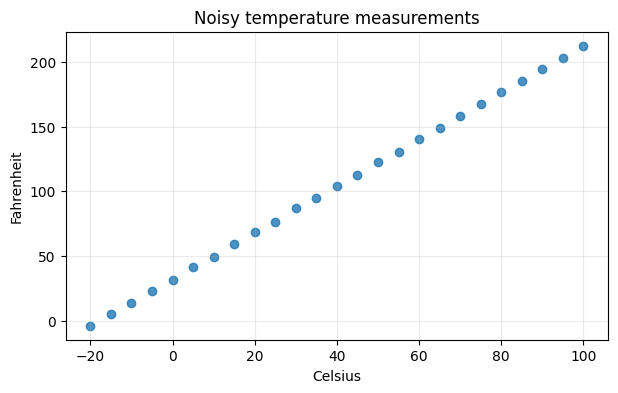

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

# Section 5 reads only the local temperature dataset.
temperature = pd.read_csv("sample_data/celsius_fahrenheit_noisy.csv")
print(temperature.head())

plt.figure(figsize=(7, 4))
plt.scatter(temperature["celsius"], temperature["fahrenheit"], alpha=0.8)
plt.xlabel("Celsius")
plt.ylabel("Fahrenheit")
plt.title("Noisy temperature measurements")
plt.grid(alpha=0.25)
plt.show()

### Define `X` and `y`, then split

`X` must be a two-dimensional feature table. `y` is the one-dimensional target. The split reserves 20% of the rows for testing.

In [2]:
X_temp = temperature[["celsius"]]
y_temp = temperature["fahrenheit"]

X_temp_train, X_temp_test, y_temp_train, y_temp_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

print(f"Training rows: {len(X_temp_train)}")
print(f"Test rows: {len(X_temp_test)}")

Training rows: 20
Test rows: 5


### Data processing and pipeline

`StandardScaler` is included to demonstrate a reusable preprocessing pipeline. Scaling is not essential for this one-feature linear regression, but the same pattern becomes important for distance-based models and neural networks.

In [3]:
temperature_model = make_pipeline(
    StandardScaler(),
    LinearRegression(),
)

temperature_model.fit(X_temp_train, y_temp_train)
temp_predictions = temperature_model.predict(X_temp_test)

temp_mae = mean_absolute_error(y_temp_test, temp_predictions)
temp_rmse = np.sqrt(mean_squared_error(y_temp_test, temp_predictions))
temp_r2 = r2_score(y_temp_test, temp_predictions)

print(f"MAE: {temp_mae:.2f} °F")
print(f"RMSE: {temp_rmse:.2f} °F")
print(f"R-squared: {temp_r2:.4f}")

MAE: 0.41 °F
RMSE: 0.44 °F
R-squared: 1.0000


### Interpret the learnt relationship

Because the input was standardised inside the pipeline, we convert the fitted coefficient back to the original Celsius scale before comparing it with the exact formula.

Learnt formula: Fahrenheit = 1.8032 × Celsius + 31.9800
Prediction for 37 °C: 98.70 °F
Exact value for 37 °C: 98.60 °F


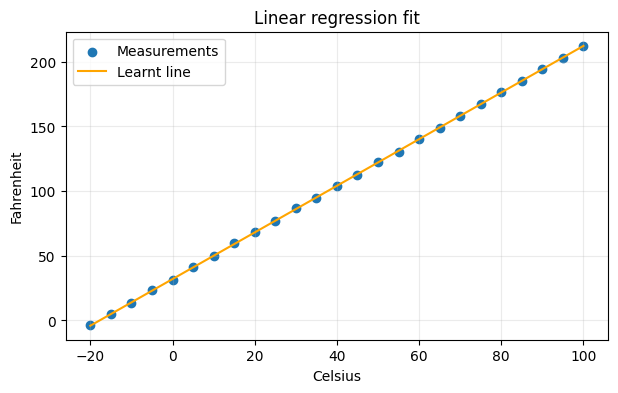

In [4]:
temp_scaler = temperature_model.named_steps["standardscaler"]
temp_regression = temperature_model.named_steps["linearregression"]

learnt_slope = temp_regression.coef_[0] / temp_scaler.scale_[0]
learnt_intercept = temp_regression.intercept_ - (
    temp_regression.coef_[0] * temp_scaler.mean_[0] / temp_scaler.scale_[0]
)

line_x = pd.DataFrame(
    {"celsius": np.linspace(temperature["celsius"].min(), temperature["celsius"].max(), 100)}
)
line_y = temperature_model.predict(line_x)

new_temperature = pd.DataFrame({"celsius": [37]})
model_prediction = temperature_model.predict(new_temperature)[0]
exact_value = 37 * 1.8 + 32

print(f"Learnt formula: Fahrenheit = {learnt_slope:.4f} × Celsius + {learnt_intercept:.4f}")
print(f"Prediction for 37 °C: {model_prediction:.2f} °F")
print(f"Exact value for 37 °C: {exact_value:.2f} °F")

plt.figure(figsize=(7, 4))
plt.scatter(temperature["celsius"], temperature["fahrenheit"], label="Measurements")
plt.plot(line_x["celsius"], line_y, color="orange", label="Learnt line")
plt.xlabel("Celsius")
plt.ylabel("Fahrenheit")
plt.title("Linear regression fit")
plt.grid(alpha=0.25)
plt.legend()
plt.show()